## Schelling's Model via Network Rewiring
This notebook implements the "Evolving Social Networks" model based on Henry, Prałat, and Zhang (2011). 

### The Mechanism:
1. **Nodes:** $N$ agents assigned to one of two groups (e.g., 0 or 1).
2. **Initial State:** A random graph (Erdős-Rényi) with a fixed number of edges.
3. **Dynamics:** 
    - At each step, an edge $(u, v)$ is chosen where nodes $u$ and $v$ are of different types.
    - With a probability $p$ (the aversion bias), this edge is **broken**.
    - To maintain the network density, the "dissatisfied" node $u$ creates a new edge with a random node $w$ that shares its same type.
4. **Goal:** Observe how the network transitions from a random state to a highly segregated (homophilous) state over time.

## 1. Environment Setup
We use `networkx` for graph manipulation and `matplotlib` for visualizing the emergence of homophily.

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
import os
# Model Parameters
N = 200            # Total number of nodes (agents)
AVG_DEGREE = 20     # Average connections per node
P_AVERSION = 0.4   # Probability 'p' of breaking a cross-group edge
RATIO = 0.5        # Balance between Group 0 and Group 1 (0.5 = 50/50)
ITERATIONS = 5000  # Total steps in the simulation
ERDOS_RENYI = True  # Set to False to use Barabási-Albert model instead of Erdős-Rényi

EVOLUTION_PLOTS = True  # Set to True to enable plotting during evolution

parent_logs = f"experiment_results_{N}_{AVG_DEGREE}_{P_AVERSION}_{RATIO}_{'ER' if ERDOS_RENYI else 'BA'}_{ITERATIONS}"
param_string = f"Parameters: N={N}, Avg Degree={AVG_DEGREE}, P Aversion={P_AVERSION}, Ratio={RATIO}, Model={'Erdős-Rényi' if ERDOS_RENYI else 'Barabási-Albert'}, Iterations={ITERATIONS}"
os.makedirs(parent_logs, exist_ok=True)
os.makedirs(f"{parent_logs}/evolutionary_graph", exist_ok=True)

## 2. Initializing the Random Graph
The simulation starts with an **Erdős-Rényi** random graph $G(n, p_{edge})$. We then randomly assign each node a "type" (0 or 1) based on the defined ratio. At this stage, the network should show very low homophily.

In [110]:
def initialize_network(n, k, ratio, erdos_renyi=True):
    p_edge = k / (n - 1)
    if erdos_renyi:
         G = nx.fast_gnp_random_graph(n, p_edge)
    else:   
        m = 3  # Number of edges to attach from a new node to existing nodes (1 <= m < n)
        G = nx.barabasi_albert_graph(n, m)
    
    nodes = list(G.nodes())
    random.shuffle(nodes)
    split = int(n * ratio)
    
    for i, node in enumerate(nodes):
        G.nodes[node]['type'] = 0 if i < split else 1
        
    return G

G = initialize_network(N, AVG_DEGREE, RATIO, ERDOS_RENYI)

## 3. Measuring Homophily
To quantify segregation, we calculate the **Homophily Index**, defined as the fraction of internal edges (same-type connections) over the total number of edges in the network.
$$H = \frac{E_{internal}}{E_{total}}$$
A value of 0.5 indicates a perfectly mixed random state, while 1.0 indicates total segregation.

In [111]:
def get_homophily(G):
    internal = 0
    total = G.number_of_edges()
    if total == 0: return 0
    
    for u, v in G.edges():
        if G.nodes[u]['type'] == G.nodes[v]['type']:
            internal += 1
    return internal / total

print(f"Initial Homophily Index: {get_homophily(G):.4f}")

Initial Homophily Index: 0.4080


## 4. The Rewiring Process
At every time step, we:
1. Identify all **cross-edges** (links between Group 0 and Group 1).
2. Randomly select one cross-edge $(u, v)$.
3. With probability $p_{aversion}$, we remove this edge.
4. To maintain a constant edge count, node $u$ creates a new edge with a random node $w$ of its **own type**.

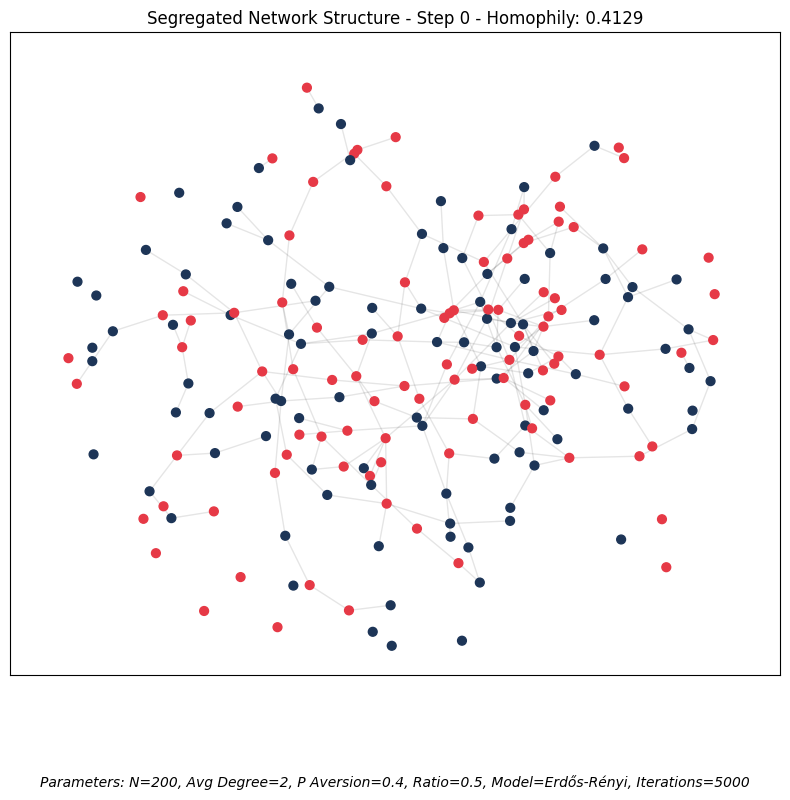

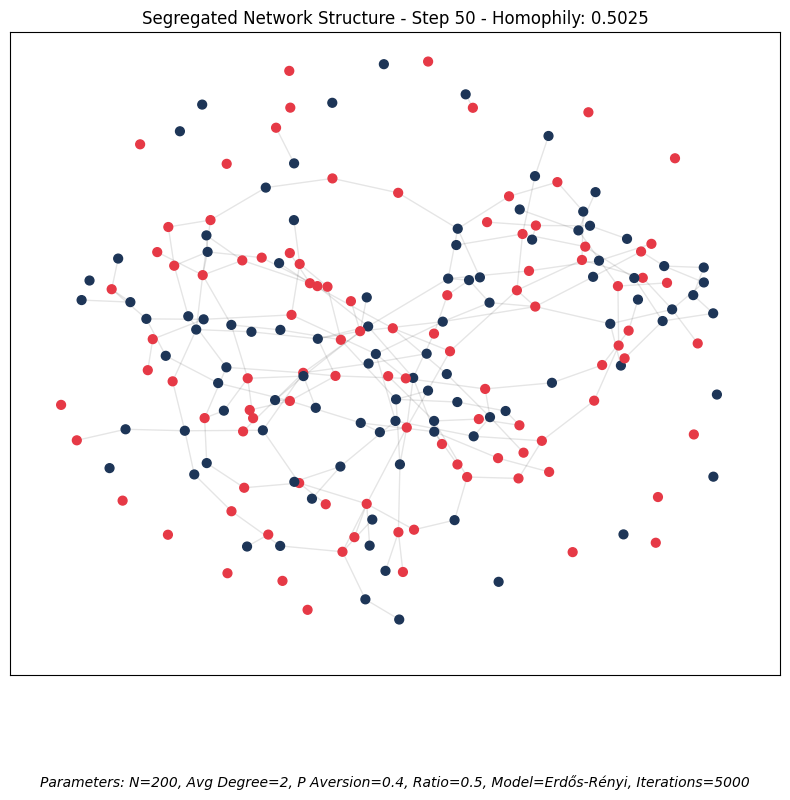

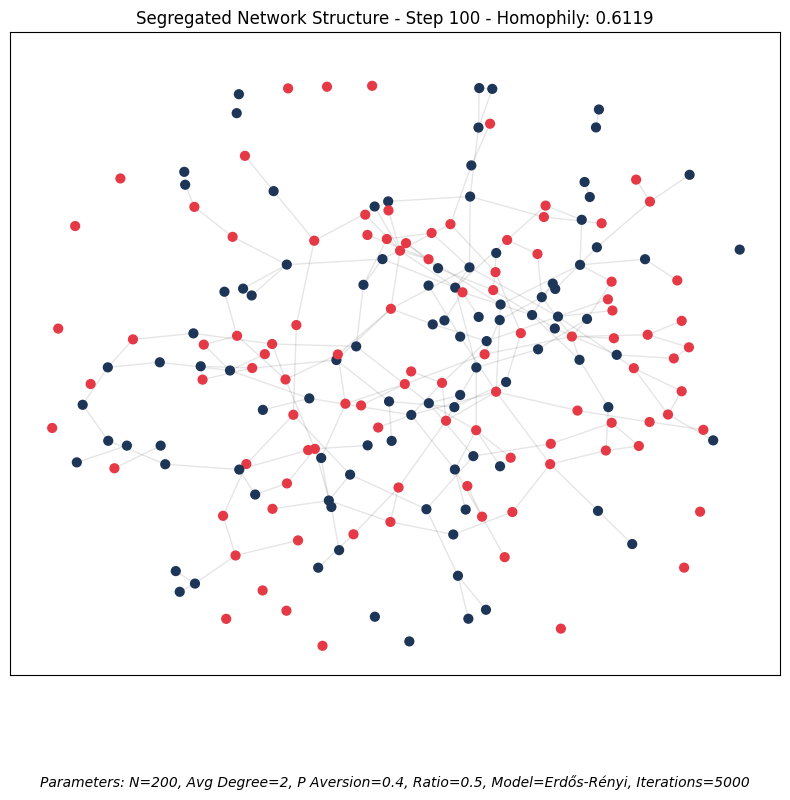

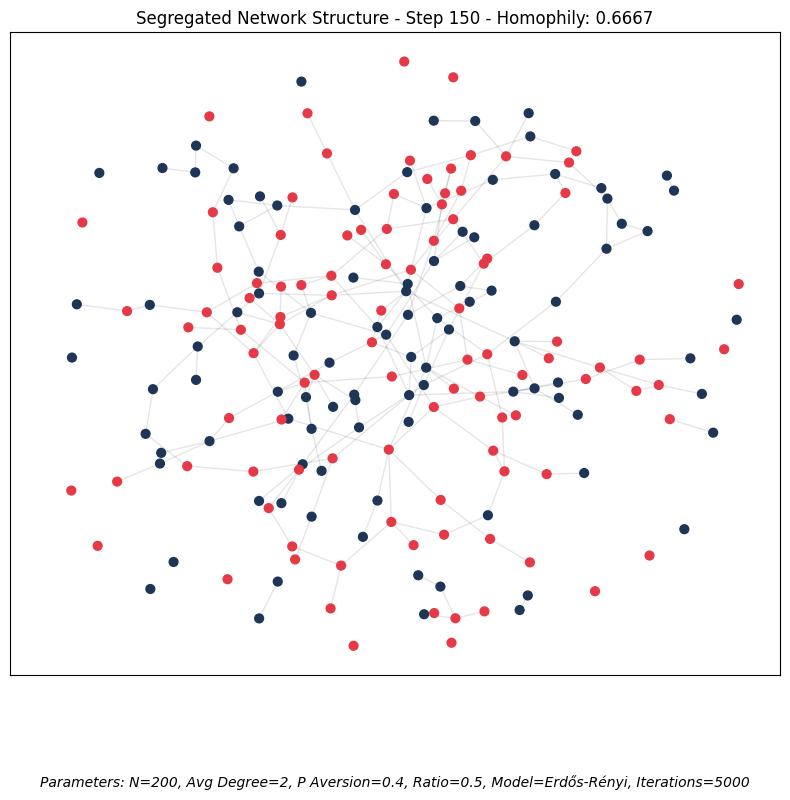

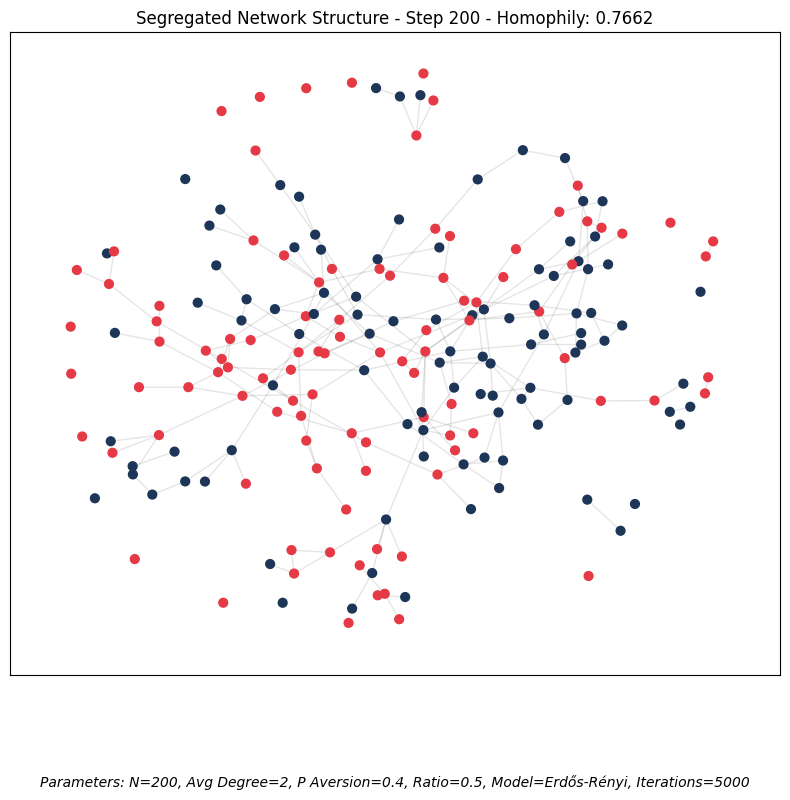

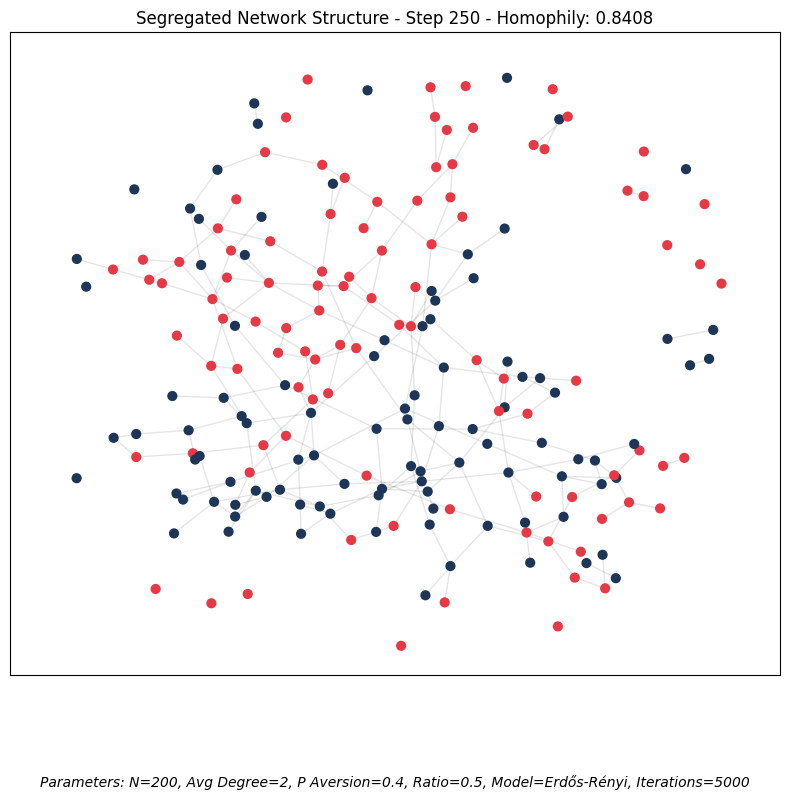

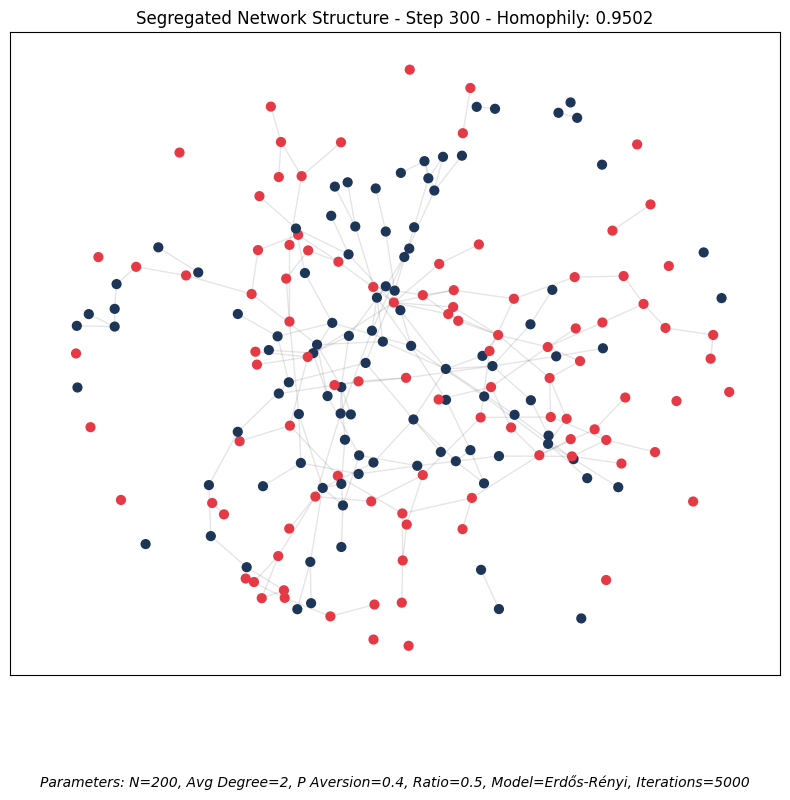

Full segregation achieved at step 323.


In [112]:
def simulate_step(G, p):
    cross_edges = [(u, v) for u, v in G.edges() if G.nodes[u]['type'] != G.nodes[v]['type']]
    
    if not cross_edges:
        return False # Simulation has reached a steady state
    
    u, v = random.choice(cross_edges)
    
    if random.random() < p:
        G.remove_edge(u, v)
        u_type = G.nodes[u]['type']
        
        potential = [n for n in G.nodes() if G.nodes[n]['type'] == u_type 
                     and n != u and not G.has_edge(u, n)]
        
        if potential:
            new_neighbor = random.choice(potential)
            G.add_edge(u, new_neighbor)
            
    return True

# Running the simulation loop
history = []
step = -1
for i in range(ITERATIONS):
    active = simulate_step(G, P_AVERSION)
    if i % 50 == 0:
        history.append(get_homophily(G))
        if EVOLUTION_PLOTS:
            fig, ax = plt.subplots(figsize=(8, 8))

            pos = nx.spring_layout(G, k=0.15)
            colors = ['#E63946' if G.nodes[n]['type'] == 0 else '#1D3557' for n in G.nodes()]
            nx.draw_networkx_nodes(G, pos, node_size=40, node_color=colors, ax=ax)
            nx.draw_networkx_edges(G, pos, alpha=0.1, ax=ax)
            ax.set_title(f"Segregated Network Structure - Step {i} - Homophily: {history[-1]:.4f}")
            plt.figtext(0.5, 0.01, param_string, wrap=True, horizontalalignment='center', fontsize=10, style='italic')

            plt.tight_layout()
            plt.subplots_adjust(bottom=0.15)
            plt.savefig(f'{parent_logs}/evolutionary_graph/step_{i}.png')
            plt.show()


    if not active:
        step=i
        break

if step == -1:
    print("Reached maximum iterations without full segregation.")
else:
    print(f"Full segregation achieved at step {step}.")
history.append(get_homophily(G))

## 5. Visualizing Segregation
We plot the evolution of the Homophily Index over time and render the final graph layout. In the graph, nodes of the same color should cluster together, forming distinct communities.

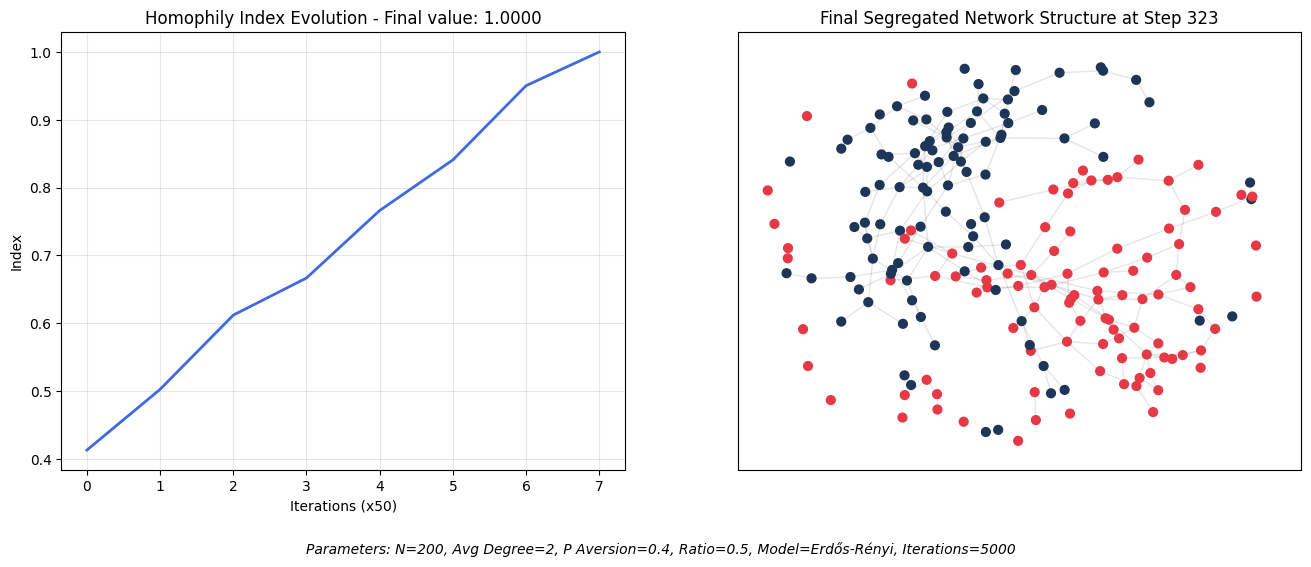

In [113]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].plot(history, color='royalblue', lw=2)
ax[0].set_title(f"Homophily Index Evolution - Final value: {history[-1]:.4f}")
ax[0].set_xlabel("Iterations (x50)")
ax[0].set_ylabel("Index")
ax[0].grid(alpha=0.3)

pos = nx.spring_layout(G, k=0.15)
colors = ['#E63946' if G.nodes[n]['type'] == 0 else '#1D3557' for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=40, node_color=colors, ax=ax[1])
nx.draw_networkx_edges(G, pos, alpha=0.1, ax=ax[1])
ax[1].set_title(f"Final Segregated Network Structure at Step {step if step != -1 else ITERATIONS}")

plt.figtext(0.5, 0.01, param_string, wrap=True, horizontalalignment='center', fontsize=10, style='italic')

plt.subplots_adjust(bottom=0.15)

plt.savefig(f'{parent_logs}/final_network.png')
plt.show()


## 6. Ensemble Analysis
Because the model is stochastic, a single run is not statistically significant. To produce robust results, we run the simulation multiple times for the same parameters and calculate the **mean** and **standard deviation**.

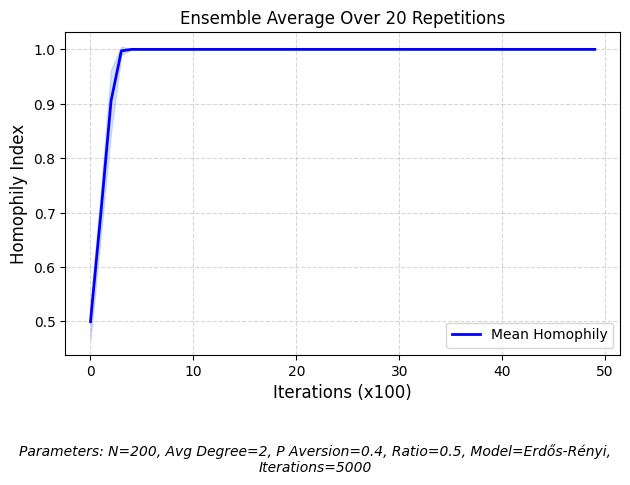

In [114]:
def run_ensemble(repeats=20):
    all_runs = []
    for _ in range(repeats):
        temp_G = initialize_network(N, AVG_DEGREE, RATIO, ERDOS_RENYI)
        run_data = []
        for i in range(ITERATIONS): 
            simulate_step(temp_G, P_AVERSION)
            if i % 100 == 0:
                run_data.append(get_homophily(temp_G))
        all_runs.append(run_data)
    return np.array(all_runs)

repeats = 20
ensemble_data = run_ensemble(repeats)
mean_h = np.mean(ensemble_data, axis=0)
std_h = np.std(ensemble_data, axis=0)



plt.fill_between(range(len(mean_h)), mean_h - std_h, mean_h + std_h, alpha=0.2, color='royalblue')
plt.plot(mean_h, label="Mean Homophily", color='blue', linewidth=2)

plt.xlabel("Iterations (x100)", fontsize=12)
plt.ylabel("Homophily Index", fontsize=12)

plt.title(f"Ensemble Average Over {repeats} Repetitions")

plt.figtext(0.5, 0.01, param_string, wrap=True, horizontalalignment='center', fontsize=10, style='italic')

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.savefig(f'{parent_logs}/ensemble_results.png')
plt.show()
